In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import re
import random

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/FP_AI_2026/models"

cnn_model = load_model(
    f"{MODEL_PATH}/cnn_model.h5"
)

print("Model Loaded")
cnn_model.summary()

Model Loaded


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 500, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (32, 496, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (32, 128)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,370,371 (5.23 MB)

 Trainable params: 1,370,369 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# Rebuild tokenizer dari training data
# (karena Keras Tokenizer tidak di-save terpisah di notebook CNN)

train_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/train.csv"
)

MAX_WORDS = 10000
MAX_LEN   = 500

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>",
    filters=""
)

tokenizer.fit_on_texts(
    train_df["Sample_Code"].astype(str)
)

print(
    "Vocabulary Size:",
    len(tokenizer.word_index)
)

Vocabulary Size: 23582


In [ ]:
test_df = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/data/test.csv"
)

print(test_df.shape)

display(test_df.head())

(100, 2)


,Sample_Code,Label
0,#include <iostream>\n#include <vector>\n\nusin...,1
1,import Java.util.Scanner;\n\npublic class Main...,0
2,public class BinarySearchTree {\n\n // Root...,0
3,#include <iostream>\n#include <cmath>\n\ndoubl...,1
4,import Java.util.Scanner;\n\npublic class Plus...,1


In [ ]:
def predict_codes(df):

    seqs = tokenizer.texts_to_sequences(
        df["Sample_Code"].astype(str)
    )

    padded = pad_sequences(
        seqs,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probs = cnn_model.predict(
        padded,
        verbose=0
    ).flatten()

    preds = (
        probs > 0.5
    ).astype(int)

    return (
        np.array(preds),
        np.array(probs)
    )

In [ ]:
original_pred, original_prob = predict_codes(
    test_df
)

y_true = test_df["Label"]

In [ ]:
original_acc = accuracy_score(
    y_true,
    original_pred
)

original_precision = precision_score(
    y_true,
    original_pred
)

original_recall = recall_score(
    y_true,
    original_pred
)

original_f1 = f1_score(
    y_true,
    original_pred
)

original_auc = roc_auc_score(
    y_true,
    original_prob
)

In [ ]:
print("Accuracy :", original_acc)
print("Precision:", original_precision)
print("Recall   :", original_recall)
print("F1       :", original_f1)
print("AUC      :", original_auc)

Accuracy : 0.96
Precision: 0.9423076923076923
Recall   : 0.98
F1       : 0.9607843137254902
AUC      : 0.9952


In [ ]:
modified_idx = test_df.sample(
    frac=0.30,
    random_state=42
).index

print(
    "Modified Samples:",
    len(modified_idx)
)

Modified Samples: 30


In [ ]:
def variable_renaming(code):

    identifiers = re.findall(
        r'\b[a-zA-Z_][a-zA-Z0-9_]*\b',
        str(code)
    )

    reserved = {

        "for","while","if","else",
        "return","class","public",
        "private","protected",

        "static","void",

        "int","float","double",
        "char","bool","boolean",

        "include","using",
        "namespace","std",

        "main",

        "cout","cin",
        "printf","scanf"
    }

    candidates = [

        x

        for x in set(identifiers)

        if x not in reserved

        and len(x) > 2

    ]

    if len(candidates) == 0:

        return code

    selected = random.sample(
        candidates,
        min(3,len(candidates))
    )

    for idx,var in enumerate(
        selected
    ):

        code = re.sub(
            rf"\b{re.escape(var)}\b",
            f"robust_var_{idx}",
            code
        )

    return code

In [ ]:
variable_df = test_df.copy()

variable_df.loc[
    modified_idx,
    "Sample_Code"
] = variable_df.loc[
    modified_idx,
    "Sample_Code"
].apply(
    variable_renaming
)

In [ ]:
changed_var = (
    test_df["Sample_Code"]
    !=
    variable_df["Sample_Code"]
).sum()

print(
    "Changed Files:",
    changed_var
)

Changed Files: 30


In [ ]:
def comment_injection(code):

    return (
        "// robustness testing comment\n"
        + str(code)
    )

In [ ]:
comment_df = test_df.copy()

comment_df.loc[
    modified_idx,
    "Sample_Code"
] = comment_df.loc[
    modified_idx,
    "Sample_Code"
].apply(
    comment_injection
)

In [ ]:
changed_com = (
    test_df["Sample_Code"]
    !=
    comment_df["Sample_Code"]
).sum()

print(
    "Changed Files:",
    changed_com
)

Changed Files: 30


In [ ]:
var_pred, var_prob = predict_codes(
    variable_df
)

In [ ]:
var_acc = accuracy_score(
    y_true,
    var_pred
)

var_precision = precision_score(
    y_true,
    var_pred
)

var_recall = recall_score(
    y_true,
    var_pred
)

var_f1 = f1_score(
    y_true,
    var_pred
)

var_auc = roc_auc_score(
    y_true,
    var_prob
)

In [ ]:
com_pred, com_prob = predict_codes(
    comment_df
)

In [ ]:
com_acc = accuracy_score(
    y_true,
    com_pred
)

com_precision = precision_score(
    y_true,
    com_pred
)

com_recall = recall_score(
    y_true,
    com_pred
)

com_f1 = f1_score(
    y_true,
    com_pred
)

com_auc = roc_auc_score(
    y_true,
    com_prob
)

In [ ]:
robustness_df = pd.DataFrame([

    {
        "Scenario":"Original",

        "Accuracy":original_acc,

        "Precision":original_precision,

        "Recall":original_recall,

        "F1":original_f1,

        "AUC":original_auc
    },

    {
        "Scenario":"Variable Renaming",

        "Accuracy":var_acc,

        "Precision":var_precision,

        "Recall":var_recall,

        "F1":var_f1,

        "AUC":var_auc
    },

    {
        "Scenario":"Comment Injection",

        "Accuracy":com_acc,

        "Precision":com_precision,

        "Recall":com_recall,

        "F1":com_f1,

        "AUC":com_auc
    }

])

robustness_df

,Scenario,Accuracy,Precision,Recall,F1,AUC
0,Original,0.96,0.942308,0.98,0.960784,0.9952
1,Variable Renaming,0.96,0.925926,1.00,0.961538,0.9944
2,Comment Injection,0.96,0.942308,0.98,0.960784,0.9952


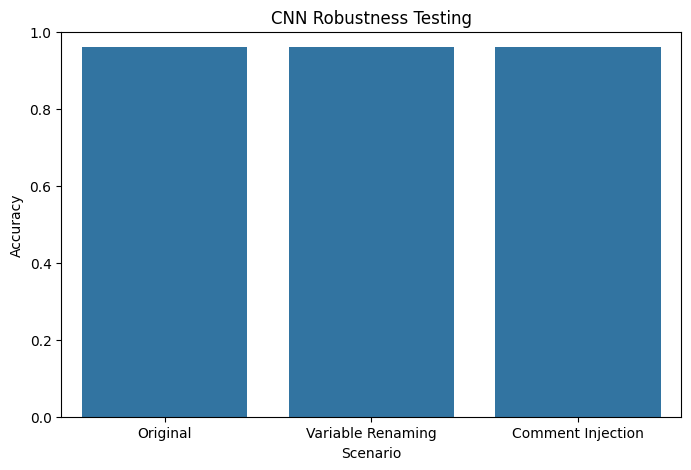

In [ ]:
plt.figure(
    figsize=(8,5)
)

sns.barplot(
    data=robustness_df,
    x="Scenario",
    y="Accuracy"
)

plt.ylim(0,1)

plt.title(
    "CNN Robustness Testing"
)

plt.show()

In [ ]:
robustness_df.to_csv(
    "/content/drive/MyDrive/FP_AI_2026/compare/robustness_results_cnn.csv",
    index=False
)

print(
    "Robustness Results Saved!"
)

Robustness Results Saved!
